# **EDA**

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


DATASET_PATH = "shimmer-raw-dataset-dehydration"

def explore(path, indent=""):
    entries = sorted(os.listdir(path))
    subdirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    csvs = [e for e in entries if e.lower().endswith('.csv')]

    print(f"{indent}{os.path.basename(path)}/  -> {len(subdirs)} folder, {len(csvs)} csv")

    if csvs and not subdirs:
        # sudah level paling dalam, tampilkan contoh nama file
        print(f"{indent}   contoh: {csvs[:3]}")
        return

    for d in subdirs:
        explore(os.path.join(path, d), indent + "  ")

explore(DATASET_PATH)


shimmer-raw-dataset-dehydration/  -> 1 folder, 0 csv
  shimmer-raw-dataset-dehydration/  -> 11 folder, 0 csv
    S1/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 24 csv
         contoh: ['20210408100028Apr8_10_00_fasting.csv', '20210413094911Apr13_09_49_fasting.csv', '20210413151934Apr13_15_19_fasting.csv']
      nonfasting/  -> 0 folder, 22 csv
         contoh: ['20210404095727Apr4_09_10_notfasting.csv', '20210404121144Apr4_12_11_notfasting.csv', '20210407085013Apr7_08_48_notfasting.csv']
    S10/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 0 csv
      nonfasting/  -> 0 folder, 1 csv
         contoh: ['20211208125944nonfasting_S10.csv']
    S11/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 0 csv
      nonfasting/  -> 0 folder, 1 csv
         contoh: ['20211210101008nonfasting_S11.csv']
    S2/  -> 2 folder, 0 csv
      fasting/  -> 0 folder, 5 csv
         contoh: ['20211007164123oct07_04_41_fasting.csv', '20211011115220oct11_11_52_fasting.csv', '20211014123108oct14_12_31

In [3]:
csv_files = [
    f for f in Path(DATASET_PATH).rglob("*.csv")
    if 'fastingtime' not in f.name.lower()
    and f.parent.name.lower() in ('fasting', 'nonfasting')
]

def extract_meta(f: Path):
    session = f.parent.name.lower()
    subject_id = f.parent.parent.name
    return subject_id, session

meta_df = pd.DataFrame([
    {"file": f.name, "path": str(f), **dict(zip(["subject_id","session_type"], extract_meta(f)))}
    for f in csv_files
])
display(pd.crosstab(meta_df['subject_id'], meta_df['session_type']))

session_type,fasting,nonfasting
subject_id,,
S1,23,22
S10,0,1
S11,0,1
S2,4,42
S3,4,4
S4,8,4
S5,4,1
S6,2,0
S7,0,1


**Total baris per subjek per sesi**

In [4]:
summary = []
for r in meta_df.itertuples():
    n_rows = sum(1 for _ in open(r.path)) - 1
    summary.append({"subject_id": r.subject_id, "session_type": r.session_type, "n_rows": n_rows})

pivot = pd.DataFrame(summary).pivot_table(
    index='subject_id', columns='session_type', values='n_rows', aggfunc='sum', fill_value=0
)
pivot

session_type,fasting,nonfasting
subject_id,,
S1,1917974,3391555
S10,0,64719
S11,0,96366
S2,154700,1648677
S3,249872,280832
S4,868862,857324
S5,65307,174583
S6,65500,0
S7,0,72411


**Pengecekan folder yang ada FastingTime.csv**

Tujuan: sumber ground truth label yang nanti dipakai buat nentuin kelas Normal/Mild/Severe Dehydration

In [5]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))
coverage = {f.parent.parent.name: f for f in fasting_time_files}

subjects_fasting = meta_df[meta_df.session_type == 'fasting']['subject_id'].unique()
for s in sorted(subjects_fasting):
    print(s, "-> ada fastingTimes.csv" if s in coverage else "-> TIDAK ADA")

S1 -> ada fastingTimes.csv
S2 -> ada fastingTimes.csv
S3 -> ada fastingTimes.csv
S4 -> ada fastingTimes.csv
S5 -> ada fastingTimes.csv
S6 -> ada fastingTimes.csv


In [6]:
for s, f in coverage.items():
    print(f"--- {s} ({f.name}) ---")
    display(pd.read_csv(f))

--- S2 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211007164123,20211007040000
1,20211011115220,20211011040000
2,20211014123108,20211014040000
3,20211014170751,20211014040000


--- S1 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20210408100028,20210408035000
1,20210413094911,20210413035000
2,20210413151934,20210413035000
3,20210414154151,20210414003000
4,20210415081723,20210415035000
5,20210415165621,20210415035000
6,20210417163344,20210417035000
7,20210418120309,20210418035000
8,20210419082504,20210419035000
9,20210420094756,20210420035000


--- S3 (fastingTimes.csv) ---


...

,RecordingTime,FastingTime
0,20211204093522,20211203230000
1,20211204100216,20211203230000
2,20211211094707,20211211000000
3,20211211100610,20211211000000


--- S4 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211203103200,20211202230000
1,20211204080716,20211203230000
2,20211204093506,20211203230000
3,20211205041234,20211204210000
4,20211209064440,20211209000000
5,20211211084723,20211211003000
6,20211211094648,20211211003000
7,20211215134443,20211215113000


--- S6 (fastingTimes.csv) ---


,RecordingTime,FastingTime
0,20211204100231,20211203230000
1,20211211100619,20211211000000


**Cek sampling rate & durasi real per subjek**

karna kenapa S1 row-nya jauh lebih banyak?

In [7]:
sample_path = meta_df.iloc[0]['path']

print("=== 5 baris mentah file (raw text) ===")
with open(sample_path) as f:
    for i in range(5):
        print(f"[{i}] {f.readline().strip()[:200]}")

print("\n=== Kolom hasil pd.read_csv default ===")
df_test = pd.read_csv(sample_path)
print(df_test.columns.tolist())

=== 5 baris mentah file (raw text) ===
[0] Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimmer_D1B2,Shimm
[1] PPG_A13,PPG_A13,Accel_LN_X,Accel_LN_X,Accel_LN_Y,Accel_LN_Y,Accel_LN_Z,Accel_LN_Z,Mag_Z,Mag_Z,Mag_X,Mag_X,System_Timestamp_Plot_Zeroed,Mag_Y,Mag_Y,Ext_Exp_A15,Ext_Exp_A15,Temperature_BMP280,Temperatur
[2] UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL,UNCAL,CAL,CAL,UNCAL,CAL,UNCAL,CAL,UNCAL,UNCAL,CAL,CAL,UNCAL,CAL,CAL,UNCAL,UNCAL,CAL,UNCAL,CAL
[3] no_units,mV,no_units,m/(s^2),m/(s^2),no_units,m/(s^2),no_units,no_units,local_flux,no_units,local_flux,ms,local_flux,no_units,no_units,mV,no_units,Degrees Celsius,no_units,kOhms,deg/s,no_units,no_unit
[4] 114,83.5164835164835,2110,8.70652173913043,1.55434782608696,1452,-3.55434782608696,2580,-422,0.632683658170914,138,0.754122938530734,40172.0886230469,

C:\Users\April\AppData\Local\Temp\ipykernel_14660\1262963674.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(sample_path)


['Shimmer_D1B2', 'Shimmer_D1B2.1', 'Shimmer_D1B2.2', 'Shimmer_D1B2.3', 'Shimmer_D1B2.4', 'Shimmer_D1B2.5', 'Shimmer_D1B2.6', 'Shimmer_D1B2.7', 'Shimmer_D1B2.8', 'Shimmer_D1B2.9', 'Shimmer_D1B2.10', 'Shimmer_D1B2.11', 'Shimmer_D1B2.12', 'Shimmer_D1B2.13', 'Shimmer_D1B2.14', 'Shimmer_D1B2.15', 'Shimmer_D1B2.16', 'Shimmer_D1B2.17', 'Shimmer_D1B2.18', 'Shimmer_D1B2.19', 'Shimmer_D1B2.20', 'Shimmer_D1B2.21', 'Shimmer_D1B2.22', 'Shimmer_D1B2.23', 'Shimmer_D1B2.24', 'Shimmer_D1B2.25', 'Shimmer_D1B2.26', 'Shimmer_D1B2.27', 'Shimmer_D1B2.28', 'Shimmer_D1B2.29', 'Shimmer_D1B2.30', 'Shimmer_D1B2.31', 'Shimmer_D1B2.32', 'Shimmer_D1B2.33', 'Shimmer_D1B2.34', 'Shimmer_D1B2.35', 'Shimmer_D1B2.36', 'Shimmer_D1B2.37']


In [8]:
def load_shimmer_csv(path):
    with open(path) as f:
        f.readline()  # baris 0: device id, skip
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()  # baris 3: units, skip

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]

    seen = {}
    colnames = []
    for name in raw_names:
        if name in seen:
            seen[name] += 1
            colnames.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            colnames.append(name)

    return pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)

df = load_shimmer_csv(sample_path)
print(df.shape)
df.head()

(388976, 38)


,PPG_A13_UNCAL,PPG_A13_CAL,Accel_LN_X_UNCAL,Accel_LN_X_CAL,Accel_LN_Y_CAL,Accel_LN_Y_UNCAL,Accel_LN_Z_CAL,Accel_LN_Z_UNCAL,Mag_Z_UNCAL,Mag_Z_CAL,...,Gyro_X_CAL,Gyro_Y_CAL,Gyro_Y_UNCAL,GSR_Skin_Conductance_CAL,GSR_Skin_Conductance_CAL_1,GSR_Skin_Conductance_UNCAL,Battery_UNCAL,Battery_CAL,Pressure_BMP280_UNCAL,Pressure_BMP280_CAL
0,114,83.516484,2110,8.706522,1.554348,1452,-3.554348,2580,-422,0.632684,...,-1.389313,1.068702,91,0.073038,0.073038,847,2795,4095.238095,4924672,100.985468
1,114,83.516484,2108,8.695652,1.576087,1453,-3.489130,2574,-410,0.614693,...,0.351145,1.862595,-23,0.073038,0.073038,847,2800,4102.564103,4924928,100.982761
2,113,82.783883,2109,8.684783,1.565217,1454,-3.554348,2580,-416,0.623688,...,1.068702,2.076336,-70,0.073038,0.073038,847,2786,4082.051282,4925184,100.980055
3,114,83.516484,2108,8.706522,1.576087,1452,-3.586957,2583,-418,0.626687,...,0.106870,0.854962,-7,0.073038,0.073038,847,2801,4104.029304,4924672,100.985468
4,112,82.051282,2107,8.728261,1.586957,1450,-3.543478,2579,-409,0.613193,...,-1.068702,0.870229,70,0.073038,0.073038,847,2811,4118.681319,4924928,100.982761


In [9]:
duplicated = [n for n in colnames if n.endswith(('_1','_2','_3'))] if 'colnames' in dir() else []
print(df.columns.tolist())

['PPG_A13_UNCAL', 'PPG_A13_CAL', 'Accel_LN_X_UNCAL', 'Accel_LN_X_CAL', 'Accel_LN_Y_CAL', 'Accel_LN_Y_UNCAL', 'Accel_LN_Z_CAL', 'Accel_LN_Z_UNCAL', 'Mag_Z_UNCAL', 'Mag_Z_CAL', 'Mag_X_UNCAL', 'Mag_X_CAL', 'System_Timestamp_Plot_Zeroed_CAL', 'Mag_Y_CAL', 'Mag_Y_UNCAL', 'Ext_Exp_A15_UNCAL', 'Ext_Exp_A15_CAL', 'Temperature_BMP280_UNCAL', 'Temperature_BMP280_CAL', 'GSR_Skin_Resistance_UNCAL', 'GSR_Skin_Resistance_CAL', 'Gyro_Z_CAL', 'Gyro_Z_UNCAL', 'GSR_Range_CAL', 'GSR_Range_UNCAL', 'Timestamp_CAL', 'Timestamp_UNCAL', 'Gyro_X_UNCAL', 'Gyro_X_CAL', 'Gyro_Y_CAL', 'Gyro_Y_UNCAL', 'GSR_Skin_Conductance_CAL', 'GSR_Skin_Conductance_CAL_1', 'GSR_Skin_Conductance_UNCAL', 'Battery_UNCAL', 'Battery_CAL', 'Pressure_BMP280_UNCAL', 'Pressure_BMP280_CAL']


In [10]:
def load_shimmer_csv(path, return_units=False):
    with open(path) as f:
        f.readline()  # device id
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        units = f.readline().strip().split(',')

    raw_names = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    seen, colnames = {}, []
    for name in raw_names:
        seen[name] = seen.get(name, -1) + 1
        colnames.append(name if seen[name] == 0 else f"{name}_{seen[name]}")

    df = pd.read_csv(path, skiprows=4, header=None, names=colnames, low_memory=False)
    return (df, dict(zip(colnames, units))) if return_units else df

df, units = load_shimmer_csv(sample_path, return_units=True)

print("--- Kandidat kolom timestamp ---")
for c in [x for x in df.columns if 'timestamp' in x.lower()]:
    print(f"{c} | unit: {units[c]} | awal: {df[c].head(2).tolist()} | akhir: {df[c].tail(2).tolist()}")

print("\n--- Kolom GSR ---")
for c in [x for x in df.columns if 'gsr' in x.lower()]:
    print(f"{c} | unit: {units[c]} | sample: {df[c].head(3).tolist()}")

--- Kandidat kolom timestamp ---
System_Timestamp_Plot_Zeroed_CAL | unit: ms | awal: [40172.0886230469, 40191.6198730469] | akhir: [7666363.49487305, 7666383.02612305]
Timestamp_CAL | unit: ms | awal: [200974.365234375, 200993.896484375] | akhir: [7827165.77148438, 7827185.30273438]
Timestamp_UNCAL | unit: Ticks | awal: [6585528, 6586168] | akhir: [4822328, 4822968]

--- Kolom GSR ---
GSR_Skin_Resistance_UNCAL | unit: no_units | sample: [847, 847, 847]
GSR_Skin_Resistance_CAL | unit: kOhms | sample: [13691.4893617021, 13691.4893617021, 13691.4893617021]
GSR_Range_CAL | unit: no_units | sample: [3, 3, 3]
GSR_Range_UNCAL | unit: no_units | sample: [3, 3, 3]
GSR_Skin_Conductance_CAL | unit: uS | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_CAL_1 | unit: microSiemens | sample: [0.073038073038073, 0.073038073038073, 0.073038073038073]
GSR_Skin_Conductance_UNCAL | unit: uS | sample: [847, 847, 847]


In [11]:
def get_duration_sr_fast(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()
    dur_sec = (ts.max() - ts.min()) / 1000
    sr = len(ts) / dur_sec if dur_sec else None
    return round(dur_sec/60, 1), round(sr, 1)

rows = []
for r in meta_df.itertuples():
    dur_min, sr = get_duration_sr_fast(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "duration_min": dur_min, "sampling_rate_hz": sr})

pd.DataFrame(rows).groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    627.6          50.356522
           nonfasting               69386.8          44.018182
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.100000
S2         fasting                     50.4          51.200000
           nonfasting                5515.8          47.678571
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    283.0          51.212500
           nonfasting                2335.4          38.575000
S5         fasting                     22.0          50.350000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.250000
S9         nonfasting                  21.3          51.200000

In [12]:
def extract_record_start(fname):
    match = re.match(r'(\d{14})', fname)
    return pd.to_datetime(match.group(1), format='%Y%m%d%H%M%S') if match else None

meta_df['record_start'] = meta_df['file'].apply(extract_record_start)
meta_df[['file', 'subject_id', 'session_type', 'record_start']].head(10)

,file,subject_id,session_type,record_start
0,20210408100028Apr8_10_00_fasting.csv,S1,fasting,2021-04-08 10:00:28
1,20210413094911Apr13_09_49_fasting.csv,S1,fasting,2021-04-13 09:49:11
2,20210413151934Apr13_15_19_fasting.csv,S1,fasting,2021-04-13 15:19:34
3,20210414154151Apr14_15_41_fasting.csv,S1,fasting,2021-04-14 15:41:51
4,20210415081723Apr15_08_17_fasting.csv,S1,fasting,2021-04-15 08:17:23
5,20210415165621April15_1656_fasting.csv,S1,fasting,2021-04-15 16:56:21
6,20210417163344April17_16_33_fasting.csv,S1,fasting,2021-04-17 16:33:44
7,20210418120309April18_12_02_fasting.csv,S1,fasting,2021-04-18 12:03:09
8,20210419082504April19_08_25_fasting.csv,S1,fasting,2021-04-19 08:25:04
9,20210420094756April20_09_47_fasting.csv,S1,fasting,2021-04-20 09:47:56


S1 non fasting ini anomali, cek dlu

In [13]:
s1_nonfasting = meta_df[(meta_df.subject_id == 'S1') & (meta_df.session_type == 'nonfasting')]

rows = []
for r in s1_nonfasting.itertuples():
    dur_min, sr = get_duration_sr_fast(r.path)
    rows.append({"file": r.file, "duration_min": dur_min, "sampling_rate_hz": sr})

per_file_df = pd.DataFrame(rows).sort_values("duration_min", ascending=False)
per_file_df

,file,duration_min,sampling_rate_hz
20,20210930071010Sep30_07_09_notfasting.csv,52661.3,0.1
10,20210911205004September11_20_50_notfasting.csv,13937.2,0.2
2,20210407085013Apr7_08_48_notfasting.csv,1889.9,0.7
17,20210923080749Sep23_08_07_notfasting.csv,216.7,51.2
21,20210930093126Sep30_09_31_notfasting.csv,150.7,51.2
12,20210915111813September14_11_18_notfasting.csv,117.2,51.2
19,20210928100207Sep28_10_01_notfasting.csv,95.2,51.2
9,20210906081335September6_08_13_notfasting.csv,84.2,51.2
0,20210404095727Apr4_09_10_notfasting.csv,69.5,51.2
8,20210901122807September1_12_28_notfasting.csv,62.3,51.2


In [14]:
bad_file = "20210930071010Sep30_07_09_notfasting.csv"
bad_path = s1_nonfasting[s1_nonfasting.file == bad_file]['path'].values[0]

df_bad = load_shimmer_csv(bad_path)
ts = pd.to_numeric(df_bad['System_Timestamp_Plot_Zeroed_CAL'], errors='coerce')

print("Jumlah baris:", len(ts))
diffs = ts.diff()
print(diffs.describe())
print("\nJumlah diff negatif:", (diffs < 0).sum())
print("Jumlah diff > 60000 ms (gap >1 menit):", (diffs > 60000).sum())
print("\n5 gap terbesar:")
print(diffs.nlargest(5))

Jumlah baris: 383977
count    383976.000000
mean       8228.849927
std       63465.116391
min           0.000000
25%          19.531250
50%          19.531250
75%          19.531250
max      511999.969483
Name: System_Timestamp_Plot_Zeroed_CAL, dtype: float64

Jumlah diff negatif: 0
Jumlah diff > 60000 ms (gap >1 menit): 5999

5 gap terbesar:
7811    511999.969483
7846    511999.969483
7887    511999.969483
7897    511999.969483
7935    511999.969483
Name: System_Timestamp_Plot_Zeroed_CAL, dtype: float64


In [15]:
def get_duration_sr_robust(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()

    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    ts_idx = colnames.index('System_Timestamp_Plot_Zeroed_CAL')

    ts = pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    ts = pd.to_numeric(ts, errors='coerce').dropna()

    if len(ts) < 2:
        return None, None, 0, None

    diffs = ts.diff().dropna()
    median_diff = diffs.median()

    if pd.isna(median_diff) or median_diff <= 0:
        return None, None, 0, None

    n_gaps = (diffs > median_diff * 5).sum()
    gap_ratio = n_gaps / len(diffs)

    dur_sec_robust = median_diff * len(ts) / 1000
    sr_robust = 1000 / median_diff
    return round(dur_sec_robust/60, 1), round(sr_robust, 1), n_gaps, round(gap_ratio*100, 2)

rows = []
for r in meta_df.itertuples():
    dur_min, sr, n_gaps, gap_pct = get_duration_sr_robust(r.path)
    rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file,
                 "duration_min": dur_min, "sampling_rate_hz": sr, "gap_pct": gap_pct})

result_df = pd.DataFrame(rows)
display(result_df.groupby(['subject_id','session_type']).agg(
    total_duration_min=('duration_min','sum'),
    avg_sampling_rate=('sampling_rate_hz','mean')
))

print("\nFile bermasalah (durasi/sampling rate gagal dihitung):")
display(result_df[result_df['duration_min'].isna()])

print("\nFile dengan gap_pct tertinggi:")
result_df.sort_values('gap_pct', ascending=False).head(10)

total_duration_min  avg_sampling_rate
subject_id session_type                                       
S1         fasting                    624.4          51.200000
           nonfasting               14976.8          48.881818
S10        nonfasting                  21.1          51.200000
S11        nonfasting                  31.4          51.200000
S2         fasting                     50.4          51.200000
           nonfasting                 529.1          50.200000
S3         fasting                     81.3          51.200000
           nonfasting                  91.4          51.200000
S4         fasting                    282.7          51.200000
           nonfasting                 279.1          51.200000
S5         fasting                     21.1          51.200000
           nonfasting                  56.8          51.200000
S6         fasting                     21.4          51.200000
S7         nonfasting                  23.6          51.200000
S8         nonfasting                  19.3          51.200000
S9         nonfasting                  21.3          51.200000


File bermasalah (durasi/sampling rate gagal dihitung):


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,NaN,NaN,NaN



File dengan gap_pct tertinggi:


,subject_id,session_type,file,duration_min,sampling_rate_hz,gap_pct
78,S2,nonfasting,20211022151633oct22_nonfast_1516.csv,32.1,51.2,29.39
110,S4,nonfasting,20211204154749nonfasting_S4.csv,29.7,51.2,27.12
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,125.0,51.2,5.83
87,S2,nonfasting,20211030151006oct30_nonfast_1509.csv,10.0,10.2,2.15
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,27.4,51.2,0.28
15,S1,fasting,20210424165256April24_16_52_fasting.csv,0.3,51.2,0.11
17,S1,fasting,20210425081128April25_08_11_fasting.csv,0.4,51.2,0.09
113,S5,fasting,20211204093522fasting20211203230000_S5.csv,11.5,51.2,0.04
11,S1,fasting,20210421155031April21_15_50_fasting.csv,0.9,51.2,0.04
30,S1,nonfasting,20210825161636Aug25_15_16_notfasting.csv,6.7,51.2,0.04


cek file bermasalah di S2 nonfasting

In [16]:
bad_path = meta_df[meta_df.file == "20211014211336oct14-afteriftar_2113.csv"]['path'].values[0]

with open(bad_path) as f:
    device_row = f.readline().strip().split(',')
    signal_row = f.readline().strip().split(',')
    caluncal_row = f.readline().strip().split(',')
    units_row = f.readline().strip().split(',')

print("Jumlah kolom signal:", len(signal_row))
print("Jumlah kolom caluncal:", len(caluncal_row))
print("Jumlah kolom units:", len(units_row))

colnames_raw = list(zip(signal_row, caluncal_row))
for i, (s, c) in enumerate(colnames_raw):
    print(i, s, c)

colnames = [f"{s}_{c}" for s, c in colnames_raw]
target = 'System_Timestamp_Plot_Zeroed_CAL'

if target in colnames:
    print("KETEMU di index:", colnames.index(target))
else:
    print("TIDAK KETEMU. Kandidat mirip:")
    print([c for c in colnames if 'timestamp' in c.lower()])

if target in colnames:
    ts_idx = colnames.index(target)
    ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts']
    print("Jumlah baris:", len(ts_raw))
    print("Contoh nilai:", ts_raw.head(5).tolist())
    print("Jumlah valid numeric:", pd.to_numeric(ts_raw, errors='coerce').notna().sum())

with open(bad_path) as f:
    total_lines = sum(1 for _ in f)
print("Total baris file (termasuk 4 header):", total_lines)
print("Baris data:", total_lines - 4)

Jumlah kolom signal: 48
Jumlah kolom caluncal: 48
Jumlah kolom units: 48
0 Accel_LN_X CAL
1 Accel_LN_X UNCAL
2 Accel_LN_Y CAL
3 Accel_LN_Y UNCAL
4 Accel_LN_Z CAL
5 Accel_LN_Z UNCAL
6 GSR_Range CAL
7 GSR_Range UNCAL
8 Timestamp UNCAL
9 Timestamp CAL
10 GSR_Skin_Conductance CAL
11 GSR_Skin_Conductance CAL
12 GSR_Skin_Conductance UNCAL
13 Battery UNCAL
14 Battery CAL
15 Pressure_BMP280 UNCAL
16 Pressure_BMP280 CAL
17 PPG_A13 UNCAL
18 PPG_A13 CAL
19 Mag_Z CAL
20 Mag_Z UNCAL
21 Mag_X CAL
22 Mag_X UNCAL
23 System_Timestamp_Plot_Zeroed CAL
24 Mag_Y UNCAL
25 Mag_Y CAL
26 Ext_Exp_A15 UNCAL
27 Ext_Exp_A15 CAL
28 Temperature_BMP280 UNCAL
29 Temperature_BMP280 CAL
30 GSR_Skin_Resistance CAL
31 GSR_Skin_Resistance UNCAL
32 Gyro_Z UNCAL
33 Gyro_Z CAL
34 Gyro_X UNCAL
35 Gyro_X CAL
36 Gyro_Y UNCAL
37 Gyro_Y CAL
38 Ext_Exp_A6 UNCAL
39 Ext_Exp_A6 CAL
40 Ext_Exp_A7 UNCAL
41 Ext_Exp_A7 CAL
42 Accel_WR_Z CAL
43 Accel_WR_Z UNCAL
44 Accel_WR_Y UNCAL
45 Accel_WR_Y CAL
46 Accel_WR_X CAL
47 Accel_WR_X UNCAL
KET

In [17]:
ts_raw = pd.read_csv(bad_path, skiprows=4, header=None, usecols=[23], names=['ts'])['ts']
ts_raw = pd.to_numeric(ts_raw, errors='coerce').dropna()

diffs = ts_raw.diff().dropna()
print("Persentase diff == 0 (timestamp stuck):", round((diffs == 0).mean() * 100, 2), "%")
print("\nTop 5 nilai diff paling sering muncul:")
print(diffs.value_counts().head(5))

Persentase diff == 0 (timestamp stuck): 97.86 %

Top 5 nilai diff paling sering muncul:
ts
0.000000          46826
100000.000000       900
5000.000000          68
1000000.000000       54
2236.480713           1
Name: count, dtype: int64


In [18]:
def check_timestamp_quality(path, ts_col='System_Timestamp_Plot_Zeroed_CAL'):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
        f.readline()
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    if ts_col not in colnames:
        return None
    ts_idx = colnames.index(ts_col)
    ts = pd.to_numeric(pd.read_csv(path, skiprows=4, header=None, usecols=[ts_idx], names=['ts'])['ts'], errors='coerce').dropna()
    if len(ts) < 2:
        return 100.0
    diffs = ts.diff().dropna()
    return round((diffs == 0).mean() * 100, 2)

quality_rows = []
for r in meta_df.itertuples():
    pct_stuck = check_timestamp_quality(r.path)
    quality_rows.append({"subject_id": r.subject_id, "session_type": r.session_type, "file": r.file, "pct_timestamp_stuck": pct_stuck})

quality_df = pd.DataFrame(quality_rows)
quality_df.sort_values('pct_timestamp_stuck', ascending=False).head(15)

,subject_id,session_type,file,pct_timestamp_stuck
64,S2,nonfasting,20211014211336oct14-afteriftar_2113.csv,97.86
43,S1,nonfasting,20210930071010Sep30_07_09_notfasting.csv,0.20
25,S1,nonfasting,20210407085013Apr7_08_48_notfasting.csv,0.02
2,S1,fasting,20210413151934Apr13_15_19_fasting.csv,0.00
4,S1,fasting,20210415081723Apr15_08_17_fasting.csv,0.00
5,S1,fasting,20210415165621April15_1656_fasting.csv,0.00
6,S1,fasting,20210417163344April17_16_33_fasting.csv,0.00
7,S1,fasting,20210418120309April18_12_02_fasting.csv,0.00
8,S1,fasting,20210419082504April19_08_25_fasting.csv,0.00
9,S1,fasting,20210420094756April20_09_47_fasting.csv,0.00


OKK FILE ITU RUSAK HARUS DIEXCLUDE

In [19]:
EXCLUDED_FILES = ["20211014211336oct14-afteriftar_2113.csv"]

meta_df_clean = meta_df[~meta_df['file'].isin(EXCLUDED_FILES)].reset_index(drop=True) # mulai skrg pake ini

In [20]:
fasting_time_files = list(set(Path(DATASET_PATH).rglob("*asting*imes.csv")))

fasting_all = pd.concat([
    pd.read_csv(f).assign(subject_id=f.parent.parent.name, source_file=f.name)
    for f in fasting_time_files
], ignore_index=True)

fasting_all

,RecordingTime,FastingTime,subject_id,source_file
0,20211007164123,20211007040000,S2,fastingTimes.csv
1,20211011115220,20211011040000,S2,fastingTimes.csv
2,20211014123108,20211014040000,S2,fastingTimes.csv
3,20211014170751,20211014040000,S2,fastingTimes.csv
4,20210408100028,20210408035000,S1,fastingTimes.csv
5,20210413094911,20210413035000,S1,fastingTimes.csv
6,20210413151934,20210413035000,S1,fastingTimes.csv
7,20210414154151,20210414003000,S1,fastingTimes.csv
8,20210415081723,20210415035000,S1,fastingTimes.csv
9,20210415165621,20210415035000,S1,fastingTimes.csv


In [21]:
# hitung durasi puasa (jam) per baris fastingTimes
fasting_all['RecordingTime'] = pd.to_datetime(fasting_all['RecordingTime'], format='%Y%m%d%H%M%S')
fasting_all['FastingTime'] = pd.to_datetime(fasting_all['FastingTime'], format='%Y%m%d%H%M%S')
fasting_all['fasting_duration_hr'] = (fasting_all['RecordingTime'] - fasting_all['FastingTime']).dt.total_seconds() / 3600
fasting_all[['subject_id','RecordingTime','FastingTime','fasting_duration_hr']]

,subject_id,RecordingTime,FastingTime,fasting_duration_hr
0,S2,2021-10-07 16:41:23,2021-10-07 04:00:00,12.689722
1,S2,2021-10-11 11:52:20,2021-10-11 04:00:00,7.872222
2,S2,2021-10-14 12:31:08,2021-10-14 04:00:00,8.518889
3,S2,2021-10-14 17:07:51,2021-10-14 04:00:00,13.130833
4,S1,2021-04-08 10:00:28,2021-04-08 03:50:00,6.174444
5,S1,2021-04-13 09:49:11,2021-04-13 03:50:00,5.986389
6,S1,2021-04-13 15:19:34,2021-04-13 03:50:00,11.492778
7,S1,2021-04-14 15:41:51,2021-04-14 00:30:00,15.197500
8,S1,2021-04-15 08:17:23,2021-04-15 03:50:00,4.456389
9,S1,2021-04-15 16:56:21,2021-04-15 03:50:00,13.105833


In [22]:
# cocokkan ke tiap file fasting di meta_df_clean via 14-digit di nama file
meta_df_clean['record_key'] = meta_df_clean['file'].str.extract(r'^(\d{14})')
fasting_all['record_key'] = fasting_all['RecordingTime'].dt.strftime('%Y%m%d%H%M%S')

meta_df_clean = meta_df_clean.merge(
    fasting_all[['record_key','fasting_duration_hr']],
    on='record_key', how='left'
)

# cek: file fasting yang GAGAL dapat durasi (harus 0 idealnya)
missing = meta_df_clean[(meta_df_clean.session_type == 'fasting') & (meta_df_clean.fasting_duration_hr.isna())]
print("File fasting tanpa match:", len(missing))
missing[['subject_id','file']]

File fasting tanpa match: 0


,subject_id,file


**Distribusi durasi puasa (buat nentuin threshold Normal/Mild/Severe)**

count    47.000000
mean      9.542813
std       3.386129
min       2.245278
25%       6.773889
50%      10.102778
75%      12.349167
max      15.197500
Name: fasting_duration_hr, dtype: float64


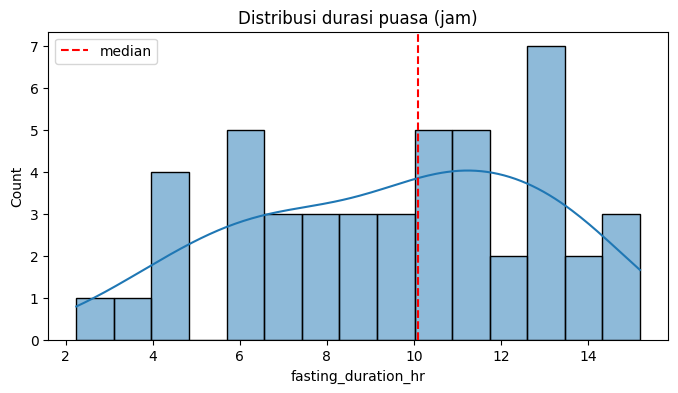

In [23]:
print(fasting_all['fasting_duration_hr'].describe())

plt.figure(figsize=(8,4))
sns.histplot(fasting_all['fasting_duration_hr'], bins=15, kde=True)
plt.axvline(fasting_all['fasting_duration_hr'].median(), color='red', linestyle='--', label='median')
plt.title("Distribusi durasi puasa (jam)")
plt.legend()
plt.show()

Threshold data fasting

In [24]:
def classify_hydration(hr):
    if hr < 10:
        return 'Well Hydrated'
    else:
        return 'At Risk of Dehydration'

fasting_all['hydration_status'] = fasting_all['fasting_duration_hr'].apply(classify_hydration)
fasting_all['hydration_status'].value_counts()

hydration_status
At Risk of Dehydration    24
Well Hydrated             23
Name: count, dtype: int64

kategori nonfasting diklasifikasikan sbg Normal karna dr dataset blg yang nonfasting ini subjek udah minum 1 jam sebelum jadi terhidrasi dong

In [26]:
meta_df_clean['hydration_status'] = np.where(
    meta_df_clean['session_type'] == 'nonfasting', 'Well Hydrated',
    meta_df_clean['fasting_duration_hr'].apply(lambda x: classify_hydration(x) if pd.notna(x) else None)
)
meta_df_clean['hydration_status'].value_counts(dropna=False)

hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [27]:
meta_df_clean = meta_df_clean.merge(
    result_df[['file', 'duration_min', 'sampling_rate_hz', 'gap_pct']],
    on='file', how='left'
)

class_duration = meta_df_clean.groupby('hydration_status')['duration_min'].sum().sort_values(ascending=False)
print(class_duration)
print("\nProporsi (%):")
print((class_duration / class_duration.sum() * 100).round(1))

hydration_status
Well Hydrated             16678.7
At Risk of Dehydration      452.5
Name: duration_min, dtype: float64

Proporsi (%):
hydration_status
Well Hydrated             97.4
At Risk of Dehydration     2.6
Name: duration_min, dtype: float64


cek ketersediaan 4 kolom sensor final (sesuai hardware: MAX30102, GSR, BME280) di semua file

In [28]:
required_cols = ['PPG_A13_CAL', 'GSR_Skin_Conductance_CAL', 'Temperature_BMP280_CAL', 'Pressure_BMP280_CAL']

def has_required_cols(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]
    return all(c in colnames for c in required_cols)

meta_df_clean['has_required_sensors'] = meta_df_clean['path'].apply(has_required_cols)
meta_df_clean['has_required_sensors'].value_counts()

has_required_sensors
True    123
Name: count, dtype: int64

# **PREPROCESSING**

In [29]:
FS = 51.2  # sampling rate hasil EDA (Hz)

valid_files = meta_df_clean[meta_df_clean['has_required_sensors']].reset_index(drop=True)
print("Total file valid untuk training:", len(valid_files))
valid_files['hydration_status'].value_counts()

Total file valid untuk training: 123


hydration_status
Well Hydrated             100
At Risk of Dehydration     23
Name: count, dtype: int64

In [32]:
def load_signals(path):
    with open(path) as f:
        f.readline()
        signal = f.readline().strip().split(',')
        caluncal = f.readline().strip().split(',')
    colnames = [f"{s}_{c}" for s, c in zip(signal, caluncal)]

    needed = {
        'ppg': 'PPG_A13_CAL',
        'gsr': 'GSR_Skin_Conductance_CAL',
        'temp': 'Temperature_BMP280_CAL',
        'pressure': 'Pressure_BMP280_CAL',
    }
    idx_map = {k: colnames.index(v) for k, v in needed.items()}

    sorted_items = sorted(idx_map.items(), key=lambda x: x[1])
    sorted_names = [k for k, _ in sorted_items]
    sorted_positions = [v for _, v in sorted_items]

    df = pd.read_csv(path, skiprows=4, header=None, usecols=sorted_positions, names=sorted_names)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna().reset_index(drop=True)

### **PPG**

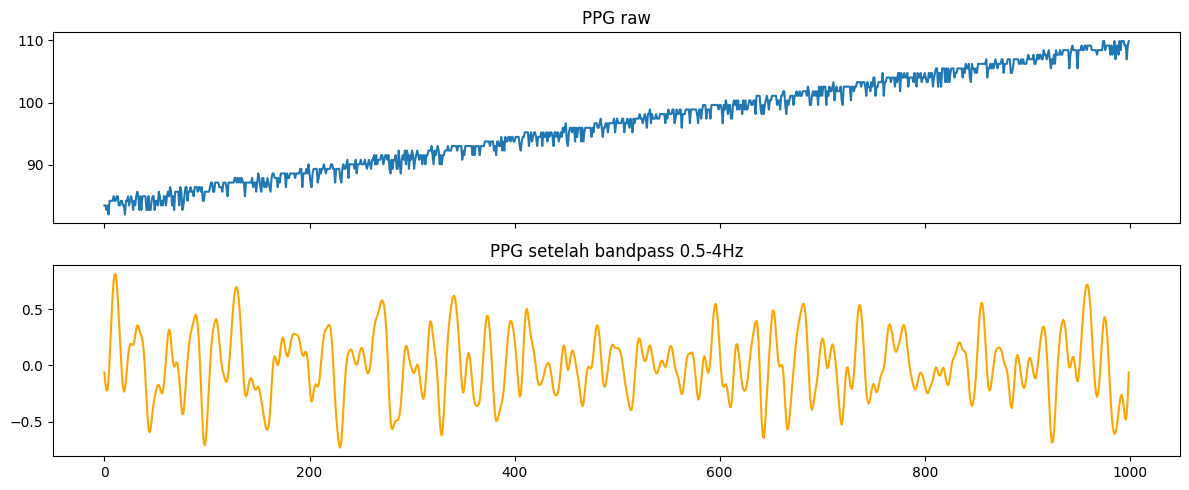

In [33]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs=FS, low=0.5, high=4.0, order=2):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

# ambil sample dari file pertama valid_files
sample_df = load_signals(valid_files.iloc[0]['path'])
sample_ppg = sample_df['ppg'].values[:1000]
filtered_ppg = bandpass_filter(sample_ppg)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(sample_ppg); axes[0].set_title("PPG raw")
axes[1].plot(filtered_ppg, color='orange'); axes[1].set_title("PPG setelah bandpass 0.5-4Hz")
plt.tight_layout(); plt.show()


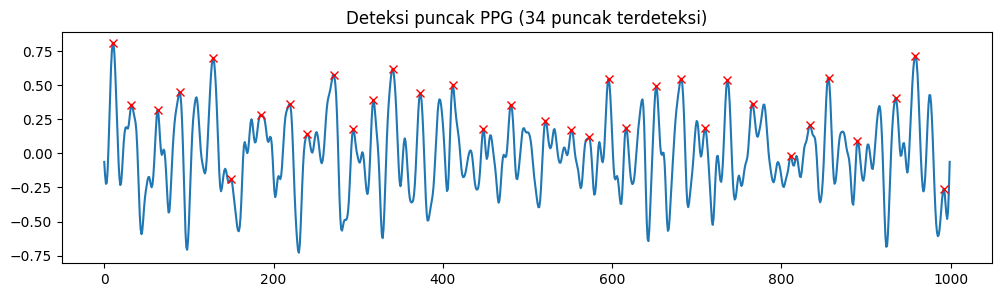

Contoh IBI (ms): [429.6875  605.46875 507.8125  781.25    410.15625 683.59375 664.0625
 410.15625 605.46875 449.21875]
Estimasi HR rata-rata: 103.23421588594705 bpm


In [42]:
# deteksi puncak PPG
from scipy.signal import find_peaks

peaks, _ = find_peaks(filtered_ppg, distance=FS*0.4)  # jarak minimum antar puncak ~0.4 detik (max 150 bpm)

plt.figure(figsize=(12,3))
plt.plot(filtered_ppg)
plt.plot(peaks, filtered_ppg[peaks], "rx")
plt.title(f"Deteksi puncak PPG ({len(peaks)} puncak terdeteksi)")
plt.show()

ibi_ms = np.diff(peaks) / FS * 1000  # interval antar-puncak dalam ms
print("Contoh IBI (ms):", ibi_ms[:10])
print("Estimasi HR rata-rata:", 60000 / ibi_ms.mean(), "bpm")

In [43]:
# hitung RMSSD dari IBI
def compute_rmssd(ibi_ms):
    diff_ibi = np.diff(ibi_ms)
    return np.sqrt(np.mean(diff_ibi**2))

def extract_ppg_features(ppg_segment, fs=FS):
    filtered = bandpass_filter(ppg_segment, fs=fs)
    peaks, _ = find_peaks(filtered, distance=fs*0.4)

    if len(peaks) < 3:
        return {'rmssd': np.nan, 'mean_hr': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'n_peaks': len(peaks)}

    ibi = np.diff(peaks) / fs * 1000
    rmssd = compute_rmssd(ibi)
    mean_hr = 60000 / ibi.mean()
    sdnn = np.std(ibi)

    diff_ibi = np.abs(np.diff(ibi))
    pnn50 = (diff_ibi > 50).sum() / len(diff_ibi) * 100 if len(diff_ibi) > 0 else np.nan

    return {'rmssd': rmssd, 'mean_hr': mean_hr, 'sdnn': sdnn, 'pnn50': pnn50, 'n_peaks': len(peaks)}

### **GSR**

In [44]:
from scipy.stats import entropy as shannon_entropy

def extract_gsr_features(gsr_segment, bins=10):
    mean_val = np.mean(gsr_segment)
    var_val = np.var(gsr_segment)
    hist, _ = np.histogram(gsr_segment, bins=bins, density=True)
    hist = hist[hist > 0]
    entropy_val = shannon_entropy(hist)
    return {'gsr_mean': mean_val, 'gsr_var': var_val, 'gsr_entropy': entropy_val}

# test ke segmen yang sama (1000 sampel pertama)
extract_gsr_features(sample_df['gsr'].values[:1000])


{'gsr_mean': np.float64(0.07359396159396175),
 'gsr_var': np.float64(3.7229129203812356e-07),
 'gsr_entropy': np.float64(1.6437766754981928)}

### **WINDOWING**

In [45]:
def create_windows(df, fs=FS, window_sec=30, overlap=0.5):
    window_size = int(window_sec * fs)
    step_size = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        windows.append(df.iloc[start:end])
    return windows

def extract_window_features(window_df):
    ppg_feats = extract_ppg_features(window_df['ppg'].values)
    gsr_feats = extract_gsr_features(window_df['gsr'].values)
    env_feats = {
        'temp_mean': window_df['temp'].mean(),
        'pressure_mean': window_df['pressure'].mean(),
    }
    return {**ppg_feats, **gsr_feats, **env_feats}

# test ke 1 file dulu
test_windows = create_windows(sample_df)
print("Jumlah window dari 1 file:", len(test_windows))

sample_features = extract_window_features(test_windows[0])
sample_features


Jumlah window dari 1 file: 505


{'rmssd': np.float64(223.41826142811416),
 'mean_hr': np.float64(96.94674556213018),
 'sdnn': np.float64(167.120454839103),
 'pnn50': np.float64(82.97872340425532),
 'n_peaks': 49,
 'gsr_mean': np.float64(0.07355578449328475),
 'gsr_var': np.float64(2.560034284494026e-07),
 'gsr_entropy': np.float64(1.4193204852724308),
 'temp_mean': np.float64(35.29190083524232),
 'pressure_mean': np.float64(100.9850961665935)}

**build feature table lengkap (dengan cap window untuk kelas Well Hydrated)**

ambil semua window dari sesi fasting (At Risk of Dehydration, minoritas – jangan sampai ada yang kebuang), tapi window dari nonfasting (Well Hydrated, mayoritas) di-sampling acak biar nggak meledak jumlahnya.

In [46]:
import random
random.seed(42)

MAX_WINDOWS_PER_FILE_WELL_HYDRATED = 100  # cap window per file khusus sesi nonfasting

all_rows = []
for i, r in enumerate(valid_files.itertuples()):
    df = load_signals(r.path)
    windows = create_windows(df)
    if r.session_type == 'nonfasting' and len(windows) > MAX_WINDOWS_PER_FILE_WELL_HYDRATED:
        windows = random.sample(windows, MAX_WINDOWS_PER_FILE_WELL_HYDRATED)
    for w in windows:
        feats = extract_window_features(w)
        feats.update({'subject_id': r.subject_id, 'session_type': r.session_type,
                      'hydration_status': r.hydration_status, 'file': r.file})
        all_rows.append(feats)

feature_df = pd.DataFrame(all_rows)
print("Total window:", len(feature_df))
feature_df.isnull().sum()


Total window: 8742


rmssd               0
mean_hr             0
sdnn                0
pnn50               0
n_peaks             0
gsr_mean            0
gsr_var             0
gsr_entropy         0
temp_mean           0
pressure_mean       0
subject_id          0
session_type        0
hydration_status    0
file                0
dtype: int64

rmssd               0
mean_hr             0
sdnn                0
pnn50               0
n_peaks             0
gsr_mean            0
gsr_var             0
gsr_entropy         0
temp_mean           0
pressure_mean       0
subject_id          0
session_type        0
hydration_status    0
file                0
dtype: int64




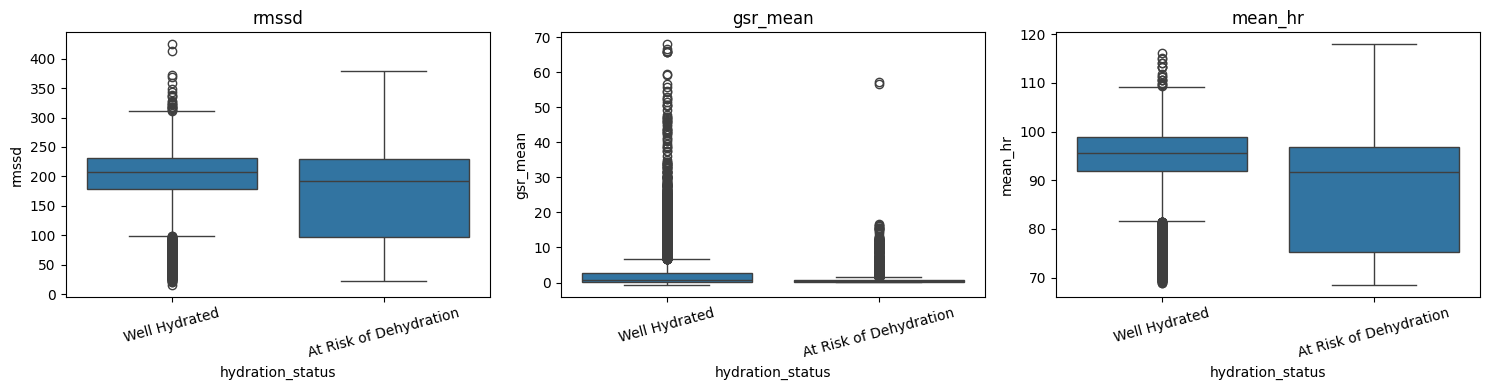

In [47]:
# cek missing value
print(feature_df.isnull().sum())
print("\n")
feature_df.describe()

# cek distribusi
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['rmssd', 'gsr_mean', 'mean_hr']):
    sns.boxplot(data=feature_df, x='hydration_status', y=col, ax=ax,
                order=['Well Hydrated','At Risk of Dehydration'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


In [48]:
pd.crosstab(feature_df['subject_id'], feature_df['hydration_status'])

hydration_status,At Risk of Dehydration,Well Hydrated
subject_id,,
S1,1114,2712
S10,0,83
S11,0,100
S2,73,2113
S3,320,292
S4,143,1277
S5,45,136
S6,82,0
S7,0,93


At Risk of Dehydration paling sedikit dan berasal dari sesi fasting yang durasinya >= 10 jam

# **SPLITTING**

In [49]:
from sklearn.model_selection import GroupKFold

test_subjects = ['S2', 'S5', 'S8', 'S11']

test_df_raw = feature_df[feature_df['subject_id'].isin(test_subjects)]

# cap window Well Hydrated dari S2 biar gak mendominasi test set
s2_well = test_df_raw[(test_df_raw.subject_id == 'S2') & (test_df_raw.hydration_status == 'Well Hydrated')].sample(n=200, random_state=42)
other_test = test_df_raw[~((test_df_raw.subject_id == 'S2') & (test_df_raw.hydration_status == 'Well Hydrated'))]

test_df_final = pd.concat([s2_well, other_test]).reset_index(drop=True)
train_subjects = [s for s in feature_df['subject_id'].unique() if s not in test_subjects]
train_df = feature_df[feature_df['subject_id'].isin(train_subjects)].reset_index(drop=True)

print("Proporsi TRAIN (%):")
print((train_df['hydration_status'].value_counts(normalize=True) * 100).round(1))
print("\nProporsi TEST (%):")
print((test_df_final['hydration_status'].value_counts(normalize=True) * 100).round(1))


Proporsi TRAIN (%):
hydration_status
Well Hydrated             73.2
At Risk of Dehydration    26.8
Name: proportion, dtype: float64

Proporsi TEST (%):
hydration_status
Well Hydrated             81.2
At Risk of Dehydration    18.8
Name: proportion, dtype: float64


# **MIN MAX NORMALIZATION**

In [50]:
feature_cols = ['rmssd', 'mean_hr', 'gsr_mean', 'gsr_var', 'gsr_entropy', 'temp_mean', 'pressure_mean']

# simpan batas dari TRAIN saja
clip_bounds = {}
for col in feature_cols:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    clip_bounds[col] = (lower, upper)

def apply_clip_and_normalize(df, bounds, fit_min_max=None):
    df = df.copy()
    for col in feature_cols:
        lower, upper = bounds[col]
        df[col] = df[col].clip(lower, upper)

    if fit_min_max is None:
        fit_min_max = {col: (df[col].min(), df[col].max()) for col in feature_cols}

    for col in feature_cols:
        mn, mx = fit_min_max[col]
        df[col] = (df[col] - mn) / (mx - mn)

    return df, fit_min_max

train_norm, minmax_bounds = apply_clip_and_normalize(train_df, clip_bounds)
test_norm, _ = apply_clip_and_normalize(test_df_final, clip_bounds, fit_min_max=minmax_bounds)

train_norm[feature_cols].describe()

,rmssd,mean_hr,gsr_mean,gsr_var,gsr_entropy,temp_mean,pressure_mean
count,6200.000000,6200.000000,6200.000000,6.200000e+03,6200.000000,6200.000000,6200.000000
mean,0.622452,0.612977,0.126906,1.460772e-02,0.740831,0.069639,0.968996
std,0.237692,0.260771,0.225601,1.056535e-01,0.220007,0.136947,0.113372
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.568119,0.546369,0.004104,1.779780e-07,0.636738,0.045610,0.974626
50%,0.683560,0.692126,0.011351,3.949644e-06,0.807023,0.053075,0.982252
75%,0.770476,0.784032,0.125930,4.485136e-04,0.906859,0.062032,0.992864
max,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000


sudah berada di rentang [0,1] semua

# **TRAINING**

In [51]:
from sklearn.ensemble import RandomForestClassifier

X_train = train_norm[feature_cols]
y_train = train_norm['hydration_status']
X_test = test_norm[feature_cols]
y_test = test_norm['hydration_status']

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Training selesai.")
print("Jumlah fitur:", X_train.shape[1])
print("Jumlah sampel train:", X_train.shape[0])

Training selesai.
Jumlah fitur: 7
Jumlah sampel train: 6200


                        precision    recall  f1-score   support

At Risk of Dehydration      0.104     0.144     0.121       118
         Well Hydrated      0.783     0.714     0.747       511

              accuracy                          0.607       629
             macro avg      0.444     0.429     0.434       629
          weighted avg      0.656     0.607     0.630       629



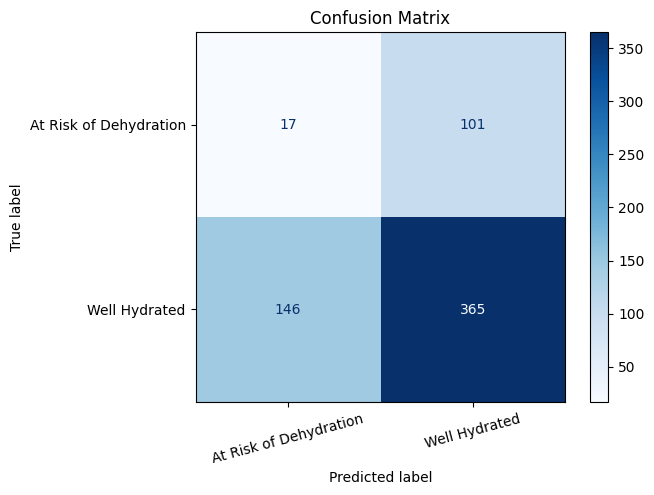

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues', xticks_rotation=15)
plt.title("Confusion Matrix")
plt.show()

alamakkk gawat bro

In [53]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

pressure_mean    0.435464
gsr_mean         0.182751
temp_mean        0.123773
mean_hr          0.083345
gsr_var          0.081239
rmssd            0.073427
gsr_entropy      0.020001
dtype: float64

re-train TANPA pressure & temp

In [54]:
physio_cols = ['rmssd', 'mean_hr', 'gsr_mean', 'gsr_var', 'gsr_entropy']

X_train_physio = train_norm[physio_cols]
X_test_physio = test_norm[physio_cols]

rf2 = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf2.fit(X_train_physio, y_train)
y_pred2 = rf2.predict(X_test_physio)

print(classification_report(y_test, y_pred2, digits=3))
pd.Series(rf2.feature_importances_, index=physio_cols).sort_values(ascending=False)

                        precision    recall  f1-score   support

At Risk of Dehydration      0.133     0.093     0.109       118
         Well Hydrated      0.804     0.859     0.831       511

              accuracy                          0.715       629
             macro avg      0.468     0.476     0.470       629
          weighted avg      0.678     0.715     0.695       629



gsr_mean       0.360205
gsr_var        0.205475
mean_hr        0.175587
rmssd          0.171965
gsr_entropy    0.086769
dtype: float64

In [55]:
feature_df.groupby('subject_id')[['mean_hr', 'gsr_mean']].agg(['mean', 'std'])

mean_hr            gsr_mean          
                  mean       std      mean       std
subject_id                                          
S1           93.677920  8.004923  5.891487  8.931711
S10          75.679360  4.659228  0.576368  0.209118
S11          95.733238  3.986597  1.833817  0.647859
S2           95.855444  5.795154  1.218379  1.693315
S3           76.123294  6.869591  0.724608  0.487043
S4           93.842199  6.700327  2.278200  6.907620
S5           89.880201  6.760961  7.804666  5.923365
S6           98.611519  4.934934  5.439937  2.418691
S7          101.128730  5.980853  0.906615  0.288315
S8           84.180808  8.848755  2.268119  0.695105
S9           94.176015  3.420702  1.966007  0.640622

In [56]:
all_feat_cols = ['rmssd', 'mean_hr', 'sdnn', 'pnn50', 'gsr_mean', 'gsr_var', 'gsr_entropy']

baseline_full = feature_df[feature_df['session_type'] == 'nonfasting'].groupby('subject_id')[all_feat_cols].mean()
global_baseline = baseline_full.mean()
for s in feature_df['subject_id'].unique():
    if s not in baseline_full.index:
        baseline_full.loc[s] = global_baseline
baseline_full

,rmssd,mean_hr,sdnn,pnn50,gsr_mean,gsr_var,gsr_entropy
subject_id,,,,,,,
S1,220.494636,96.489809,158.422936,80.572818,8.253596,37.575819,1.805889
S10,126.873540,75.679360,98.065385,48.736770,0.576368,0.002362,1.958845
S11,227.415869,95.733238,163.332780,81.734513,1.833817,0.054467,2.063496
S2,185.913469,96.209179,137.413655,62.305257,1.186960,12.357354,1.939064
S3,112.543094,75.006086,86.688537,47.965882,1.102863,0.005995,2.080999
S4,171.253591,90.984787,127.931294,62.270880,6.759347,91.507795,1.863560
S5,234.693357,88.567092,176.926330,82.477509,12.533799,2.664957,2.059310
S7,165.541261,101.128730,117.109834,51.128572,0.906615,0.007659,1.951334
S8,181.841138,84.180808,141.400749,72.599527,2.268119,0.022781,2.078726


In [57]:
delta_cols = [f"{c}_delta" for c in all_feat_cols]

feature_df_delta = feature_df.copy()
for c in all_feat_cols:
    feature_df_delta[f"{c}_delta"] = feature_df_delta.apply(
        lambda row: row[c] - baseline_full.loc[row['subject_id'], c], axis=1
    )

feature_df_delta[delta_cols].describe()

,rmssd_delta,mean_hr_delta,sdnn_delta,pnn50_delta,gsr_mean_delta,gsr_var_delta,gsr_entropy_delta
count,8742.000000,8742.000000,8742.000000,8742.000000,8742.000000,8742.000000,8742.000000
mean,-0.041362,-0.667050,0.216106,-0.145628,-1.862268,-22.685082,0.005068
std,57.822988,7.412538,37.729136,18.392259,6.849506,132.201133,0.333702
min,-200.746981,-27.946198,-145.921071,-80.572818,-11.703624,-91.507795,-1.923685
25%,-23.956298,-3.520612,-14.392741,-6.572818,-7.473696,-37.575813,-0.112730
50%,2.900823,0.266097,3.174039,1.245363,-0.984875,-37.428337,0.088342
75%,32.583942,3.795334,20.267154,10.359657,0.156174,-12.346836,0.210794
max,266.924013,28.099641,192.022271,49.470016,61.164045,2751.835782,0.496275


In [58]:
train_df_d = feature_df_delta[feature_df_delta['subject_id'].isin(train_subjects)].reset_index(drop=True)

test_raw_d = feature_df_delta[feature_df_delta['subject_id'].isin(test_subjects)]
s2_well_d = test_raw_d[(test_raw_d.subject_id == 'S2') & (test_raw_d.hydration_status == 'Well Hydrated')].sample(n=200, random_state=42)
other_test_d = test_raw_d[~((test_raw_d.subject_id == 'S2') & (test_raw_d.hydration_status == 'Well Hydrated'))]
test_df_d = pd.concat([s2_well_d, other_test_d]).reset_index(drop=True)

clip_bounds_d = {c: (train_df_d[c].quantile(0.01), train_df_d[c].quantile(0.99)) for c in delta_cols}

def clip_norm_delta(df, bounds, fit_mm=None):
    df = df.copy()
    for c in delta_cols:
        lo, hi = bounds[c]
        df[c] = df[c].clip(lo, hi)
    if fit_mm is None:
        fit_mm = {c: (df[c].min(), df[c].max()) for c in delta_cols}
    for c in delta_cols:
        mn, mx = fit_mm[c]
        df[c] = (df[c] - mn) / (mx - mn) if mx > mn else 0.0
    return df, fit_mm

train_norm_d, mm_d = clip_norm_delta(train_df_d, clip_bounds_d)
test_norm_d, _ = clip_norm_delta(test_df_d, clip_bounds_d, fit_mm=mm_d)

train_norm_d[delta_cols].describe()


,rmssd_delta,mean_hr_delta,sdnn_delta,pnn50_delta,gsr_mean_delta,gsr_var_delta,gsr_entropy_delta
count,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000
mean,0.556290,0.606944,0.550373,0.629260,0.167625,0.417304,0.721648
std,0.192745,0.194986,0.185949,0.200935,0.217703,0.254965,0.212947
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.480857,0.540808,0.481706,0.577796,0.005627,0.466411,0.622302
50%,0.574436,0.631753,0.568258,0.649639,0.050760,0.466413,0.776913
75%,0.671540,0.723155,0.655653,0.746863,0.243060,0.469358,0.878379
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [59]:
X_train_d = train_norm_d[delta_cols]
y_train_d = train_norm_d['hydration_status']
X_test_d = test_norm_d[delta_cols]
y_test_d = test_norm_d['hydration_status']

rf3 = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf3.fit(X_train_d, y_train_d)
y_pred_d = rf3.predict(X_test_d)

print(classification_report(y_test_d, y_pred_d, digits=3))
pd.Series(rf3.feature_importances_, index=delta_cols).sort_values(ascending=False)

                        precision    recall  f1-score   support

At Risk of Dehydration      0.113     0.153     0.129       118
         Well Hydrated      0.787     0.722     0.753       511

              accuracy                          0.615       629
             macro avg      0.450     0.437     0.441       629
          weighted avg      0.660     0.615     0.636       629



gsr_mean_delta       0.324187
gsr_var_delta        0.216734
pnn50_delta          0.114586
mean_hr_delta        0.111909
rmssd_delta          0.105234
sdnn_delta           0.078995
gsr_entropy_delta    0.048356
dtype: float64

hasilnya jelek jg

In [60]:
physio_delta_cols = ['rmssd_delta', 'mean_hr_delta', 'sdnn_delta', 'pnn50_delta', 'gsr_mean_delta', 'gsr_var_delta', 'gsr_entropy_delta']

X_all = feature_df_delta[physio_delta_cols]
y_all = feature_df_delta['hydration_status']
groups = feature_df_delta['subject_id']

gkf = GroupKFold(n_splits=5)
rf_cv = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

y_pred_cv = cross_val_predict(rf_cv, X_all, y_all, cv=gkf, groups=groups)

print(classification_report(y_all, y_pred_cv, digits=3))

NameError: name 'cross_val_predict' is not defined

In [ ]:
rf_cv.fit(X_all, y_all)  # fit sekali lagi di seluruh data buat lihat importance
pd.Series(rf_cv.feature_importances_, index=physio_delta_cols).sort_values(ascending=False)

cek apakah training BENAR-BENAR belajar sesuatu, atau cuma nebak mayoritas? Uji dengan cross-validation per subjek (bukan 1x split)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GroupKFold

X_all = feature_df_delta[physio_delta_cols]
y_all = feature_df_delta['hydration_status']
groups = feature_df_delta['subject_id']

gkf = GroupKFold(n_splits=5)
rf_cv = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

y_pred_cv = cross_val_predict(rf_cv, X_all, y_all, cv=gkf, groups=groups)

print(classification_report(y_all, y_pred_cv, digits=3))